# Prueba 2 — ThinkDSP

Resolución sencilla, paso a paso.

In [14]:
from __future__ import print_function, division
%matplotlib inline

import sys
sys.path.append('..')
import thinkdsp
import matplotlib.pyplot as plt

---
## Ejercicio 1

La señal `diente_sierra.wav` fue muestreada a 9000 muestras/s. Se pide establecer su frecuencia fundamental y reconstruirla filtrando las componentes con aliasing, si es posible.

### Solución

Primero cargamos y normalizamos la señal.

In [15]:
wave1 = thinkdsp.read_wave('diente_sierra.wav')
wave1.normalize()
wave1.make_audio()

Observamos el espectro. Una onda diente de sierra contiene armónicos pares e impares.

Text(0.5, 1.0, 'Espectro de la señal')

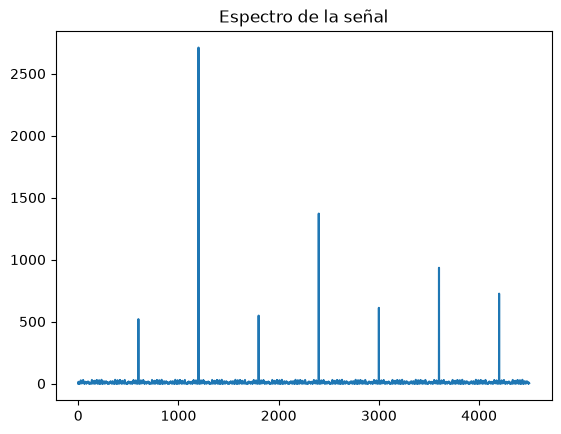

In [16]:
spectrum1 = wave1.make_spectrum()
spectrum1.plot()
plt.title('Espectro de la señal')

La frecuencia de Nyquist es la mitad de la frecuencia de muestreo. Las componentes superiores a este valor se pliegan y producen aliasing.

In [17]:
nyquist = wave1.framerate / 2
print('Frecuencia de muestreo:', wave1.framerate, 'Hz')
print('Frecuencia de Nyquist:', nyquist, 'Hz')

Frecuencia de muestreo: 9000 Hz
Frecuencia de Nyquist: 4500.0 Hz


El primer pico está cerca de 1200 Hz, por lo que esa es la fundamental. Construimos una señal diente de sierra de 1200 Hz para comparar los espectros.

Text(0.5, 1.0, 'Espectro de una diente de sierra de 1200 Hz')

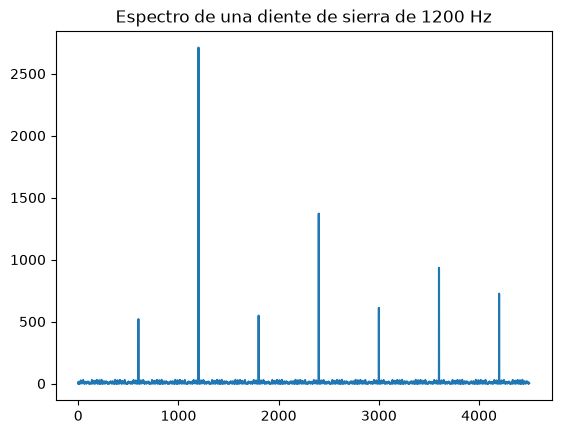

In [18]:
thinkdsp.SawtoothSignal(1200).make_wave(framerate=wave1.framerate).make_spectrum().plot()
plt.title('Espectro de una diente de sierra de 1200 Hz')

Para reconstruir sólo la fundamental, dejamos pasar las frecuencias cercanas a 1200 Hz y eliminamos el resto.

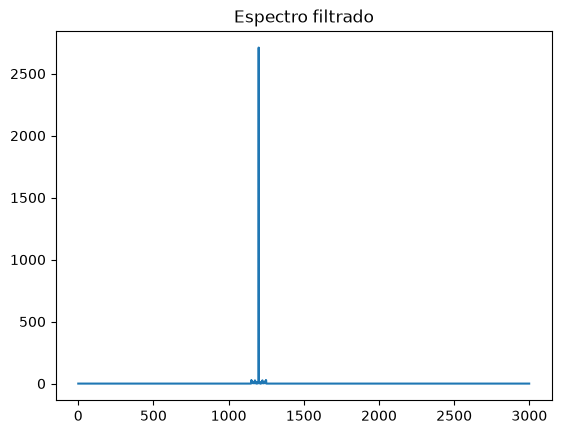

In [19]:
spectrum1.high_pass(1150)
spectrum1.low_pass(1250)
spectrum1.plot(high=3000)
plt.title('Espectro filtrado')

wave1_filtrada = spectrum1.make_wave()
wave1_filtrada.normalize()
wave1_filtrada.make_audio()

**Conclusión:** la frecuencia fundamental es **1200 Hz**. La frecuencia de Nyquist es **4500 Hz**. Los armónicos sobre 4500 Hz generan aliasing; al filtrar entre 1150 y 1250 Hz se conserva únicamente la fundamental.

---
## Ejercicio 2

La señal `desconocida2.wav` dura tres segundos. Se debe describir usando análisis temporal y espectrogramas.

### Solución

Primero cargamos la señal.

In [20]:
wave2 = thinkdsp.read_wave('desconocida2.wav')
wave2.normalize()
wave2.make_audio()

Generamos espectrogramas con dos tamaños de segmento. Los segmentos cortos muestran mejor cuándo cambia la señal; los largos muestran mejor sus frecuencias.

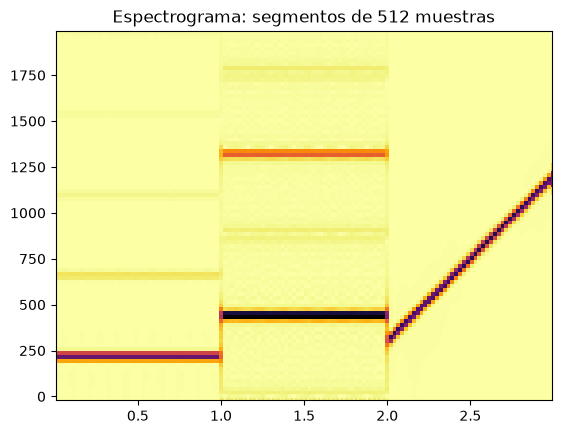

In [21]:
for largo in [256, 512]:
    spectrogram = wave2.make_spectrogram(largo)
    spectrogram.plot(high=2000)
    plt.title(f'Espectrograma: segmentos de {largo} muestras')

Ahora analizamos por separado un segmento de cada segundo.

(0.0, 2000.0)

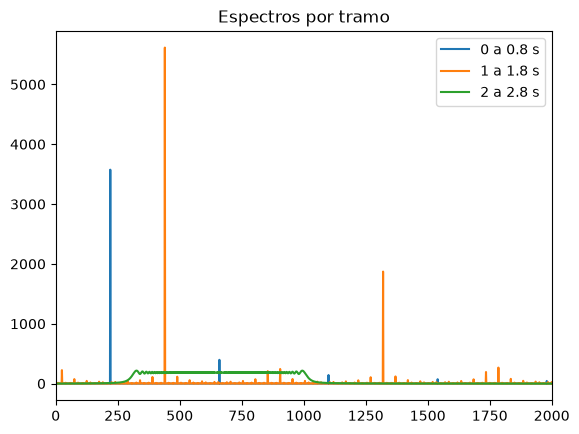

In [22]:
for inicio in [0, 1, 2]:
    segmento = wave2.segment(start=inicio, duration=0.8)
    segmento.make_spectrum().plot(label=f'{inicio} a {inicio + 0.8} s')

plt.legend()
plt.title('Espectros por tramo')
plt.xlim(0, 2000)

**Conclusión:**

- Entre 0 y 1 s hay una **onda triangular de 220 Hz**: aparecen armónicos impares que disminuyen rápidamente.
- Entre 1 y 2 s hay una **onda cuadrada de 440 Hz**: también tiene armónicos impares, pero con mayor presencia en altas frecuencias.
- Entre 2 y 3 s hay un **chirp lineal cosenoidal**: la frecuencia aumenta aproximadamente de 300 a 1200 Hz.

Las líneas horizontales del espectrograma indican frecuencias constantes y la línea inclinada final indica una frecuencia que cambia con el tiempo.

---
## Ejercicio 3

La señal `incognita2.wav` puede contener una señal débil enmascarada por ruido. Las opciones son: triangular de 1000 Hz, triangular de 1800 Hz, diente de sierra de 1400 Hz o cosenoidal de 600 Hz.

### Solución

Primero cargamos la señal.

In [23]:
wave3 = thinkdsp.read_wave('incognita2.wav')
wave3.normalize()
wave3.make_audio()

En el dominio del tiempo domina el ruido, por lo que es difícil reconocer directamente la forma de onda.

Text(0.5, 1.0, 'Segmento temporal de la señal con ruido')

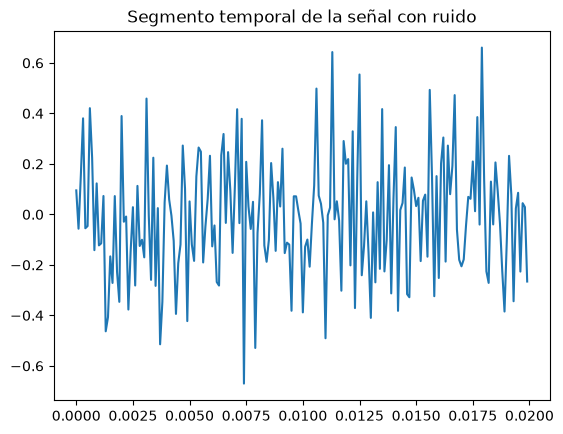

In [24]:
wave3.segment(start=0, duration=0.02).plot()
plt.title('Segmento temporal de la señal con ruido')

El espectro permite ver los picos de la señal por encima del nivel de ruido.

Text(0.5, 1.0, 'Espectro de la señal recibida')

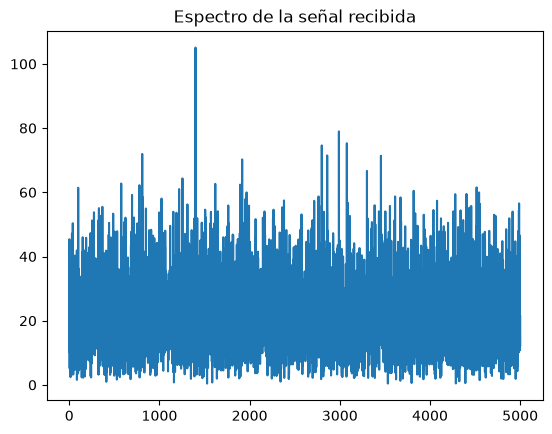

In [25]:
spectrum3 = wave3.make_spectrum()
spectrum3.plot()
plt.title('Espectro de la señal recibida')

Comparamos las cuatro opciones. Una cosenoide tiene un solo pico; una triangular tiene sólo armónicos impares; una diente de sierra tiene armónicos pares e impares.

(0.0, 6000.0)

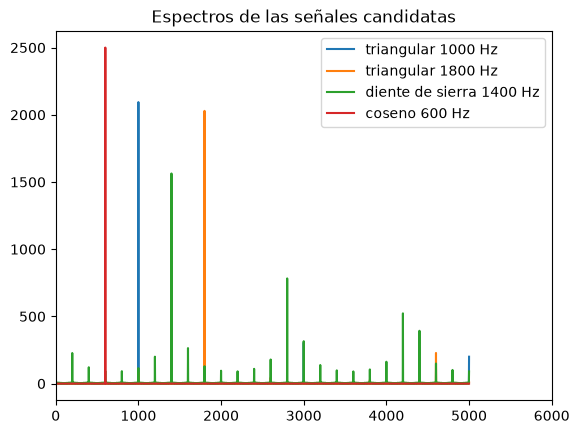

In [26]:
candidatos = {
    'triangular 1000 Hz': thinkdsp.TriangleSignal(1000),
    'triangular 1800 Hz': thinkdsp.TriangleSignal(1800),
    'diente de sierra 1400 Hz': thinkdsp.SawtoothSignal(1400),
    'coseno 600 Hz': thinkdsp.CosSignal(600),
}

for nombre, senal in candidatos.items():
    senal.make_wave(duration=0.5, framerate=wave3.framerate).make_spectrum().plot(label=nombre)

plt.legend()
plt.title('Espectros de las señales candidatas')
plt.xlim(0, 6000)

**Conclusión:** sí hay una señal enmascarada. Es una **onda diente de sierra de 1400 Hz**: el espectro muestra una fundamental cercana a 1400 Hz y varios armónicos pares e impares sobre el ruido. Esto descarta la cosenoide, que tendría un solo pico, y las triangulares, que sólo tendrían armónicos impares.